#📌 Extracción

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_telecomx = pd.read_csv('datos_tratados.csv')
df_telecomx

,id,Churn,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_de_internet,...,proteccion_de_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,factura_digital,metodo_de_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Si,Yes,9,Si,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Si,Si,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Male,0,No,No,4,Si,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Si,Male,1,Si,No,13,Si,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Female,1,Si,No,3,Si,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Si,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7028,9992-RRAMN,Si,Male,0,Si,No,22,Si,Si,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7029,9992-UJOEL,No,Male,0,No,No,2,Si,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7030,9993-LHIEB,No,Male,0,Si,Yes,67,Si,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [ ]:
#verificar valores unicos de la tabla
for col in df_telecomx.columns:
  print(f'{col}: {df_telecomx[col].nunique()}')
  if df_telecomx[col].nunique() < 50:
    print(df_telecomx[col].unique())
    print('-' * 50)

id: 7032
Churn: 2
['No' 'Si']
--------------------------------------------------
genero: 2
['Female' 'Male']
--------------------------------------------------
tiene_+60: 2
[0 1]
--------------------------------------------------
tiene_pareja: 2
['Si' 'No']
--------------------------------------------------
tiene_dependientes: 2
['Yes' 'No']
--------------------------------------------------
tiempo_contrato: 72
servicio_telefono: 2
['Si' 'No']
--------------------------------------------------
multiples_lineas: 3
['No' 'Si' 'Sin servicio telefónico']
--------------------------------------------------
tipo_de_internet: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
seguridad_en_linea: 3
['No' 'Yes' 'No internet service']
--------------------------------------------------
respaldo_en_linea: 3
['Yes' 'No' 'No internet service']
--------------------------------------------------
proteccion_de_dispositivo: 3
['No' 'Yes' 'No internet service']
---------------

In [ ]:
columnas_a_estandarizar = [
    'Churn', 'tiene_pareja', 'tiene_dependientes', 'servicio_telefono',
    'multiples_lineas', 'seguridad_en_linea', 'respaldo_en_linea',
    'proteccion_de_dispositivo', 'soporte_tecnico', 'streaming_tv',
    'streaming_peliculas', 'factura_digital'
]


cambios = {
    'Yes': 'Si',
    'No internet service': 'No',
    'No phone service': 'Sin servicio telefónico',
    'Sin servicio telefónico':'No'
}

# Apply replacements to the specified columns
for col in columnas_a_estandarizar:
    if col in df_telecomx.columns:
        df_telecomx.loc[:, col] = df_telecomx[col].replace(cambios)

# Display a sample of the DataFrame to show the changes
df_telecomx.sample(10)


,id,Churn,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_de_internet,...,proteccion_de_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,factura_digital,metodo_de_pago,valor_mensual,total_cobrado,Cuentas_Diarias
2396,3439-GVUSX,No,Male,0,No,No,1,No,No,DSL,...,No,No,No,No,Month-to-month,No,Mailed check,24.40,24.40,0.813333
2721,3882-IYOIJ,No,Female,0,Si,Si,60,Si,Si,Fiber optic,...,Si,Si,Si,Si,Two year,No,Credit card (automatic),115.25,6758.45,3.841667
5738,8087-LGYHQ,No,Male,0,No,No,9,Si,No,Fiber optic,...,Si,No,Si,Si,Month-to-month,Si,Electronic check,94.05,811.65,3.135000
392,0580-PIQHM,No,Female,0,Si,Si,41,Si,Si,Fiber optic,...,Si,No,No,Si,One year,Si,Bank transfer (automatic),101.60,3930.55,3.386667
5175,7295-JOMMD,Si,Female,0,No,Si,4,Si,No,Fiber optic,...,Si,Si,Si,Si,Month-to-month,Si,Bank transfer (automatic),98.10,396.30,3.270000
3194,4588-YBNIB,Si,Female,0,No,No,1,Si,No,No,...,No,No,No,No,Month-to-month,Si,Mailed check,19.60,19.60,0.653333
5461,7698-YFGEZ,No,Male,0,No,No,1,Si,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,20.00,20.00,0.666667
205,0320-JDNQG,Si,Male,0,Si,Si,23,Si,No,Fiber optic,...,No,Si,Si,Si,Month-to-month,Si,Electronic check,99.85,2331.30,3.328333
6128,8699-ASUFO,Si,Male,1,Si,No,7,Si,Si,Fiber optic,...,No,No,No,No,Month-to-month,Si,Mailed check,74.40,527.90,2.480000
4529,6397-JNZZG,Si,Female,1,Si,No,43,No,No,DSL,...,Si,No,Si,Si,Month-to-month,No,Credit card (automatic),55.55,2342.20,1.851667


In [ ]:
#verificar valores unicos de la tabla
for col in df_telecomx.columns:
  print(f'{col}: {df_telecomx[col].nunique()}')
  if df_telecomx[col].nunique() < 50:
    print(df_telecomx[col].unique())
    print('-' * 50)

id: 7032
Churn: 2
['No' 'Si']
--------------------------------------------------
genero: 2
['Female' 'Male']
--------------------------------------------------
tiene_+60: 2
[0 1]
--------------------------------------------------
tiene_pareja: 2
['Si' 'No']
--------------------------------------------------
tiene_dependientes: 2
['Si' 'No']
--------------------------------------------------
tiempo_contrato: 72
servicio_telefono: 2
['Si' 'No']
--------------------------------------------------
multiples_lineas: 2
['No' 'Si']
--------------------------------------------------
tipo_de_internet: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
seguridad_en_linea: 2
['No' 'Si']
--------------------------------------------------
respaldo_en_linea: 2
['Si' 'No']
--------------------------------------------------
proteccion_de_dispositivo: 2
['No' 'Si']
--------------------------------------------------
soporte_tecnico: 2
['Si' 'No']
-----------------------------

In [ ]:
#removiendo datos innecesarios para su manipulación como el ID
df_telecomx = df_telecomx.drop(columns=['id'])

In [ ]:
df_telecomx.sample(10)

,Churn,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_de_internet,seguridad_en_linea,...,proteccion_de_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,factura_digital,metodo_de_pago,valor_mensual,total_cobrado,Cuentas_Diarias
5690,No,Female,0,No,No,55,Si,Si,Fiber optic,Si,...,Si,No,No,No,One year,Si,Credit card (automatic),84.25,4589.85,2.808333
3777,No,Male,0,Si,No,71,Si,No,No,No,...,No,No,No,No,One year,No,Electronic check,20.85,1539.75,0.695000
2712,Si,Female,0,No,No,2,Si,No,DSL,Si,...,No,No,Si,Si,Month-to-month,Si,Electronic check,70.75,146.90,2.358333
5258,No,Male,0,No,No,9,Si,No,Fiber optic,No,...,No,Si,Si,Si,Month-to-month,Si,Bank transfer (automatic),95.90,827.45,3.196667
2159,Si,Female,1,Si,No,27,Si,Si,Fiber optic,Si,...,No,Si,Si,Si,Month-to-month,Si,Bank transfer (automatic),104.30,2867.75,3.476667
3423,No,Male,1,Si,Si,66,Si,Si,Fiber optic,Si,...,Si,Si,Si,Si,One year,Si,Electronic check,116.25,7862.25,3.875000
4184,Si,Female,0,Si,No,19,Si,Si,Fiber optic,No,...,Si,No,No,Si,Month-to-month,No,Mailed check,89.65,1761.05,2.988333
5997,Si,Female,0,No,No,5,Si,No,Fiber optic,No,...,No,Si,No,Si,Month-to-month,Si,Electronic check,89.35,461.70,2.978333
3501,No,Male,1,Si,No,19,No,No,DSL,No,...,Si,No,No,No,Month-to-month,Si,Credit card (automatic),34.30,577.15,1.143333
3623,No,Male,0,No,No,4,Si,No,No,No,...,No,No,No,No,Month-to-month,Si,Mailed check,19.95,59.25,0.665000


In [ ]:
#verificación de valores nulos
df_telecomx.isnull().sum()

,0
Churn,0
genero,0
tiene_+60,0
tiene_pareja,0
tiene_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_de_internet,0
seguridad_en_linea,0


Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de _machine learning_. Utiliza un método de codificación adecuado, como **one-hot encoding**.

🔎 **Sugerencia:**
Puedes consultar este artículo para entender mejor cuándo usar `get_dummies` o `OneHotEncoder`:
[Artículo en Alura sobre codificación categórica](http://falta-link.com "‌")

# 🛠️ Pre Preparación de los Datos

In [ ]:
# === Opción 1: Usando .replace() para columnas binarias ('Si'/'No') ===

# Lista de columnas binarias a convertir usando .replace()
binary_cols_for_replace = [
    'tiene_pareja', 'tiene_dependientes', 'servicio_telefono',
    'multiples_lineas', 'seguridad_en_linea', 'respaldo_en_linea',
    'proteccion_de_dispositivo', 'soporte_tecnico', 'streaming_tv',
    'streaming_peliculas', 'factura_digital'
]

# Convertir los datos de la columna 'tiene_+60' a booleana (0 -> False, 1 -> True)
df_telecomx["tiene_+60"] = df_telecomx["tiene_+60"].astype(bool)

# Mapeo para 'Si'/'No' a 1/0
mapping_si_no_to_binary = {'Si': 1, 'No': 0}

# Aplicar el mapeo a las columnas seleccionadas
for col in binary_cols_for_replace:
    if col in df_telecomx.columns:
        df_telecomx.loc[:, col] = df_telecomx[col].replace(mapping_si_no_to_binary)

# Manejar la columna 'genero' por separado si tiene 'Female'/'Male'
if 'genero' in df_telecomx.columns:
    df_telecomx.loc[:, 'genero'] = df_telecomx['genero'].replace({'Female': 0, 'Male': 1})

print("DataFrame después de aplicar .replace() a columnas binarias:")
# Solo mostrar las columnas que fueron modificadas en este paso, además de 'genero'
print(df_telecomx[list(set(binary_cols_for_replace) & set(df_telecomx.columns)) + (['genero'] if 'genero' in df_telecomx.columns else [])].sample(5))
print("\n" + "-"*50 + "\n")


# === Aplicar One-Hot Encoding con pd.get_dummies() para todas las categóricas restantes ===
# Esta es la alternativa y el método recomendado para múltiples categorías y también para binarias.

# Identificar columnas categóricas para one-hot encoding
# Excluir columnas que ya son numéricas o identificadores (como 'Churn' que ya debe ser 0/1)
categorical_cols = df_telecomx.select_dtypes(include='object').columns.tolist()

# Churn debe ser numérico a estas alturas. Si no lo fuera, debería convertirse antes de este paso.

print("Columnas categóricas a transformar con get_dummies:", categorical_cols)

# Aplicar pd.get_dummies
df_telecomx_encoded = pd.get_dummies(df_telecomx, columns=categorical_cols, drop_first=True)

print("DataFrame después de aplicar pd.get_dummies:")
df_telecomx_encoded.head()


DataFrame después de aplicar .replace() a columnas binarias:
     multiples_lineas factura_digital proteccion_de_dispositivo  \
960                 0               0                         0   
675                 0               1                         0   
5974                1               1                         0   
3399                1               1                         1   
6908                1               1                         0   

     streaming_peliculas soporte_tecnico tiene_pareja servicio_telefono  \
960                    0               0            1                 0   
675                    0               0            0                 1   
5974                   0               0            0                 1   
3399                   1               0            1                 1   
6908                   0               0            1                 1   

     streaming_tv respaldo_en_linea seguridad_en_linea tiene_dependientes  \
960     

/tmp/ipykernel_197/4247010213.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecomx.loc[:, col] = df_telecomx[col].replace(mapping_si_no_to_binary)
/tmp/ipykernel_197/4247010213.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecomx.loc[:, 'genero'] = df_telecomx['genero'].replace({'Female': 0, 'Male': 1})


,tiene_+60,tiempo_contrato,valor_mensual,total_cobrado,Cuentas_Diarias,Churn_Si,genero_1,tiene_pareja_1,tiene_dependientes_1,servicio_telefono_1,...,proteccion_de_dispositivo_1,soporte_tecnico_1,streaming_tv_1,streaming_peliculas_1,contrato_One year,contrato_Two year,factura_digital_1,metodo_de_pago_Credit card (automatic),metodo_de_pago_Electronic check,metodo_de_pago_Mailed check
0,False,9,65.6,593.30,2.186667,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,False,9,59.9,542.40,1.996667,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,False,4,73.9,280.85,2.463333,True,True,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,True,13,98.0,1237.85,3.266667,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,True,3,83.9,267.40,2.796667,True,False,True,False,True,...,False,True,True,False,False,False,True,False,False,True


Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 **Sugerencia:**
Puedes usar `value_counts()` de pandas para obtener esta proporción:
[Documentación oficial de ](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html "‌")`value_counts()`

In [ ]:
# Calcula la cantidad de clientes por cada valor de la columna 'Churn'
# 'No' indica que el cliente no canceló, 'Si' indica que sí canceló.
cancelaciones_counts = df_telecomx['Churn'].value_counts()

# Calcula la proporción (porcentaje) de clientes para cada valor de 'Churn'
# Se divide por el total de clientes y se multiplica por 100 para obtener el porcentaje.
proporcion_cancelaciones = (cancelaciones_counts / len(df_telecomx)) * 100

# Imprime los resultados de las cantidades de clientes
print("Cantidad de clientes por estado de cancelación:")
print(cancelaciones_counts)

# Imprime los resultados de la proporción de clientes en porcentaje
print("\nProporción de clientes por estado de cancelación (%):")
print(proporcion_cancelaciones)

# Evalúa si existe un desbalance de clases
# Generalmente, un desbalance se considera significativo si una clase es mucho más pequeña que otra.
# Por ejemplo, si una clase es menos del 20-30% de la otra.

# Obtiene el valor más pequeño y más grande de la proporción
min_proporcion = proporcion_cancelaciones.min()
max_proporcion = proporcion_cancelaciones.max()

# Define un umbral para considerar desbalance (ej: si la clase minoritaria es < 30% de la mayoritaria)
# Puedes ajustar este umbral según tu dominio y las necesidades del modelo.
umbral_desbalance = 30

# Verifica si la clase minoritaria es significativamente más pequeña que la mayoritaria
if min_proporcion / max_proporcion * 100 < umbral_desbalance:
    print(f"\n¡Advertencia! Existe un desbalance significativo entre las clases de 'Churn'.\n" \
          f"La clase minoritaria representa el {min_proporcion:.2f}% y la mayoritaria el {max_proporcion:.2f}%.\n" \
          "Esto podría afectar el rendimiento de los modelos predictivos.")
else:
    print("\nNo se observa un desbalance significativo entre las clases de 'Churn'.")


Cantidad de clientes por estado de cancelación:
Churn
No    5163
Si    1869
Name: count, dtype: int64

Proporción de clientes por estado de cancelación (%):
Churn
No    73.421502
Si    26.578498
Name: count, dtype: float64

No se observa un desbalance significativo entre las clases de 'Churn'.


#🎯 Correlación y Selección de Variables

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial **atención a las variables que muestran una mayor correlación con la cancelación**, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

/tmp/ipykernel_197/2692399222.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecomx['Churn'] = df_telecomx['Churn'].replace({'Si': 1, 'No': 0})


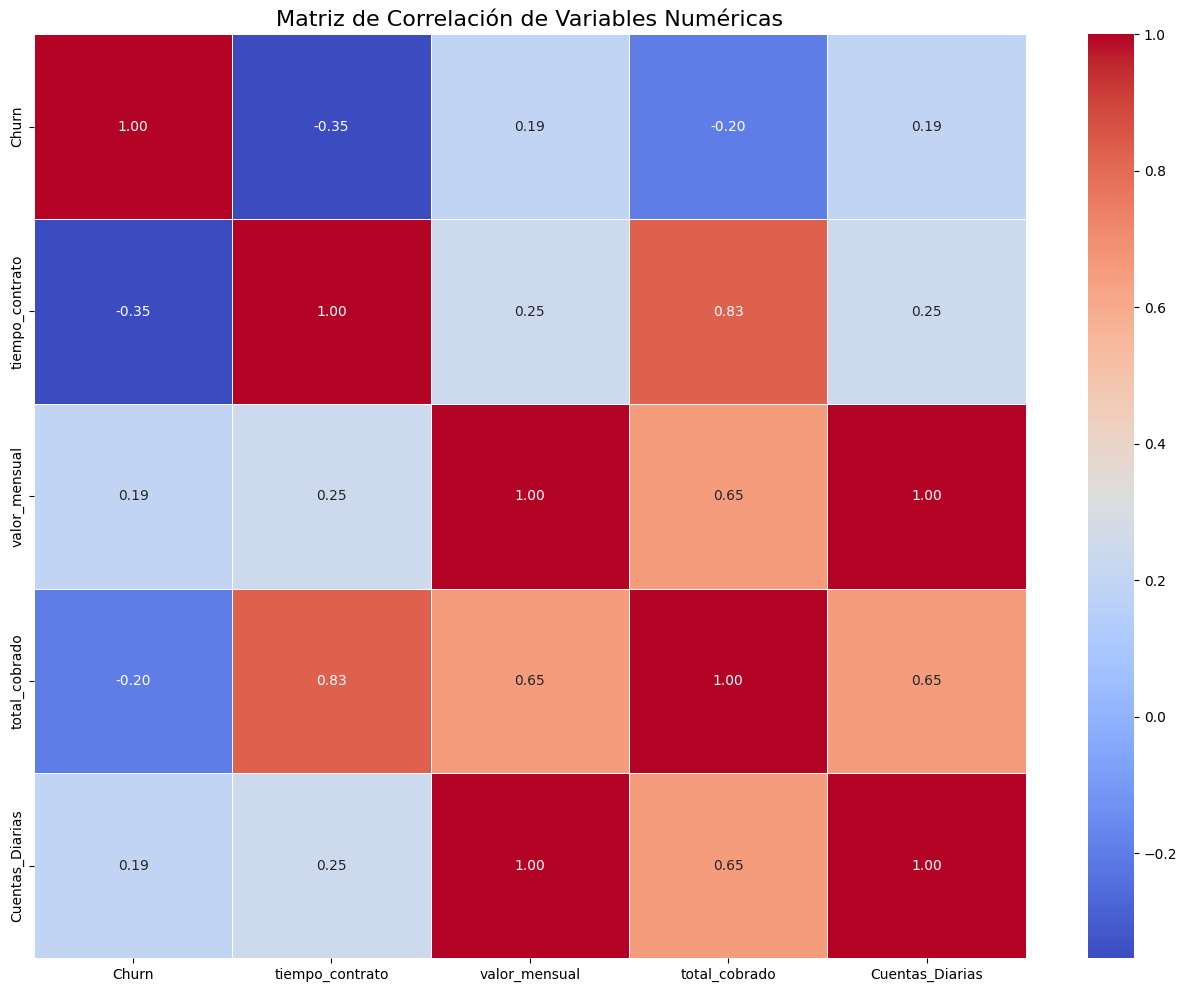


Correlación de las variables numéricas con 'Churn':
Churn              1.000000
Cuentas_Diarias    0.192858
valor_mensual      0.192858
total_cobrado     -0.199484
tiempo_contrato   -0.354049
Name: Churn, dtype: float64


In [ ]:
# Asegurarse de que la columna 'Churn' sea numérica (0 o 1)
# Esto es necesario si la celda de estandarización anterior no se ha ejecutado o si se ejecuta esta celda de forma aislada.
df_telecomx['Churn'] = df_telecomx['Churn'].replace({'Si': 1, 'No': 0})

# Seleccionar solo las columnas numéricas del DataFrame
df_numericas = df_telecomx.select_dtypes(include=['number'])

# Calcular la matriz de correlación
matriz_correlacion = df_numericas.corr()

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

# Mostrar las correlaciones con la variable 'Churn' para una revisión más detallada
print("\nCorrelación de las variables numéricas con 'Churn':")
print(matriz_correlacion['Churn'].sort_values(ascending=False))


In [ ]:
df_telecomx = df_telecomx.drop(columns=["Cuentas_Diarias","total_cobrado"])

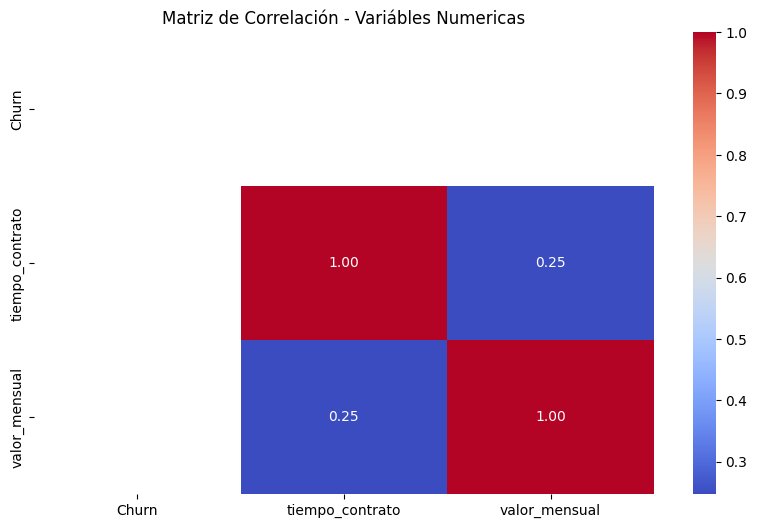

In [ ]:
df_numeric = df_telecomx.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df_telecomx["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


In [ ]:
# Asegurarse de que la columna 'Churn' sea numérica (0 o 1) si no lo está ya
# Esta línea es para asegurar que si se ejecuta esta celda de forma aislada, 'Churn' sea 0/1
# En el flujo actual del notebook, 'Churn' ya debería ser numérica.
if df_telecomx['Churn'].dtype == 'object':
    df_telecomx['Churn'] = df_telecomx['Churn'].replace({'Si': 1, 'No': 0})

# Seleccionar solo las columnas numéricas del DataFrame
df_numericas_simples = df_telecomx.select_dtypes(include=['number'])

# Calcular la matriz de correlación
matriz_correlacion_simple = df_numericas_simples.corr()

print("Matriz de Correlación (Tabla Sencilla):")
print(matriz_correlacion_simple.round(2))

print("\n" + "-"*50 + "\n")

# Mostrar las correlaciones con la variable 'Churn' para una revisión más detallada
print("Correlación de las variables numéricas con 'Churn' (orden descendente):")
print(matriz_correlacion_simple['Churn'].sort_values(ascending=False).round(2))


Matriz de Correlación (Tabla Sencilla):
                 Churn  tiempo_contrato  valor_mensual
Churn             1.00            -0.35           0.19
tiempo_contrato  -0.35             1.00           0.25
valor_mensual     0.19             0.25           1.00

--------------------------------------------------

Correlación de las variables numéricas con 'Churn' (orden descendente):
Churn              1.00
valor_mensual      0.19
tiempo_contrato   -0.35
Name: Churn, dtype: float64


## Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

- **Tiempo de contrato × Cancelación**
- **Gasto total × Cancelación**

Utiliza gráficos como **boxplots** o **scatter plots** para visualizar patrones y posibles tendencias.

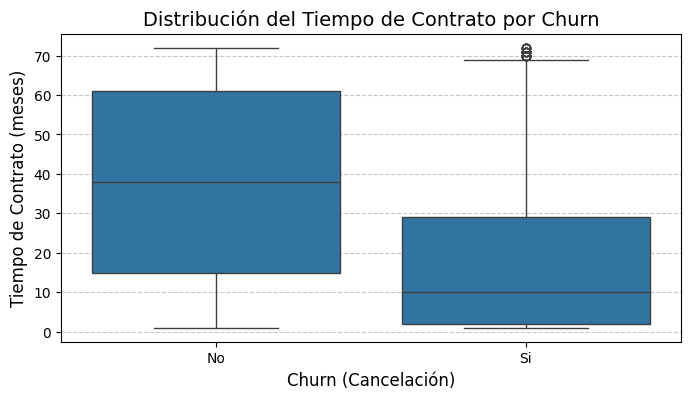


---

La columna 'total_cobrado' fue eliminada en una celda anterior. En su lugar, 
se visualizará la relación entre 'valor_mensual' y 'Churn'.



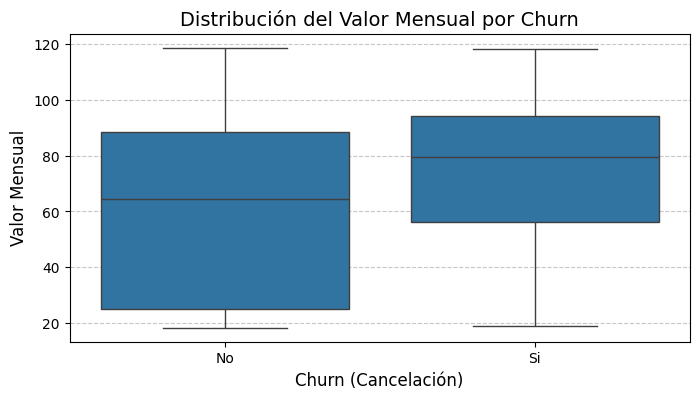

In [ ]:
# Asegurarse de que 'Churn' sea numérica (0 y 1) y renombrar para los gráficos si es necesario
# (ya fue convertido a 0/1 en una celda anterior para la matriz de correlación)
# Sin embargo, para la visualización es mejor usar etiquetas descriptivas.
# Crearemos una copia temporal para no modificar la columna original de Churn para futuras operaciones si se espera 'Si'/'No'
df_temp = df_telecomx.copy()
df_temp['Churn_labels'] = df_temp['Churn'].map({1: 'Si', 0: 'No'})

# 1. Boxplot para 'tiempo_contrato' vs 'Churn'
plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn_labels', y='tiempo_contrato', data=df_temp)
plt.title('Distribución del Tiempo de Contrato por Churn', fontsize=14)
plt.xlabel('Churn (Cancelación)', fontsize=12)
plt.ylabel('Tiempo de Contrato (meses)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n---\n")

# Explicar que 'total_cobrado' fue eliminada y usar 'valor_mensual' como alternativa
print("La columna 'total_cobrado' fue eliminada en una celda anterior. En su lugar, \n"\
      "se visualizará la relación entre 'valor_mensual' y 'Churn'.\n")

# 2. Boxplot para 'valor_mensual' vs 'Churn'
plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn_labels', y='valor_mensual', data=df_temp)
plt.title('Distribución del Valor Mensual por Churn', fontsize=14)
plt.xlabel('Churn (Cancelación)', fontsize=12)
plt.ylabel('Valor Mensual', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
df_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7032 non-null   int64  
 1   genero                     7032 non-null   object 
 2   tiene_+60                  7032 non-null   bool   
 3   tiene_pareja               7032 non-null   object 
 4   tiene_dependientes         7032 non-null   object 
 5   tiempo_contrato            7032 non-null   int64  
 6   servicio_telefono          7032 non-null   object 
 7   multiples_lineas           7032 non-null   object 
 8   tipo_de_internet           7032 non-null   object 
 9   seguridad_en_linea         7032 non-null   object 
 10  respaldo_en_linea          7032 non-null   object 
 11  proteccion_de_dispositivo  7032 non-null   object 
 12  soporte_tecnico            7032 non-null   object 
 13  streaming_tv               7032 non-null   objec

##Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 **Sugerencia:**
Puedes usar `value_counts()` de pandas para obtener esta proporción:
[Documentación oficial de ](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html "‌")`value_counts()`

In [ ]:

#Tablas de contingencia
categorical_cols = df_telecomx.select_dtypes(include=["object"]).columns
# Asegurarse de que 'Churn' sea eliminada solo si existe en categorical_cols para evitar un KeyError
if 'Churn' in categorical_cols:
    categorical_cols = categorical_cols.drop("Churn")

for col in categorical_cols:
    print(f"\n Churn en:  {col}")
    # Asegurarse de que la columna 'Churn' esté en el DataFrame
    if 'Churn' in df_telecomx.columns:
        display(pd.crosstab(df_telecomx[col], df_telecomx["Churn"], normalize="index") * 100)
    else:
        print(f"La columna 'Churn' no se encontró en el DataFrame para analizar con {col}.")


 Churn en:  genero


Churn,0,1
genero,,
0,73.040482,26.959518
1,73.795435,26.204565



 Churn en:  tiene_pareja


Churn,0,1
tiene_pareja,,
0,67.023908,32.976092
1,80.282935,19.717065



 Churn en:  tiene_dependientes


...

Churn,0,1
contrato,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



 Churn en:  factura_digital


Churn,0,1
factura_digital,,
0,83.624302,16.375698
1,66.410749,33.589251



 Churn en:  metodo_de_pago


Churn,0,1
metodo_de_pago,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Prueba Chi-cuadrado ($\chi^2$) de Independencia:

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia de df_telecomx
df_rank = df_telecomx.copy()

# La columna 'Churn' ya es binaria (0/1)
# por lo que no es necesario volver a mapearla. Si no lo fuera, se haria:
# df_rank["Churn"] = df_rank["Churn"].map({"Si": 1, "No": 0})

# Separar variables categóricas (que aún sean 'object' después de la estandarización)
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding a las columnas categóricas
# LabelEncoder transforma cada categoría en un número entero único.
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar las características categóricas codificadas (X_cat) y la variable objetivo (y)
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar la prueba de Chi-cuadrado para selección de características
# Esta función calcula el estadístico Chi-cuadrado y el p-value para cada característica.
chi_scores, p_values = chi2(X_cat, y)

# Crear un DataFrame con el ranking de las variables
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por el score de Chi-cuadrado (mayor score indica mayor dependencia con la variable objetivo)
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

print("Ranking de variables categóricas por su relación con 'Churn' :\n")
chi_df

Ranking de variables categóricas por su relación con 'Churn' :



,Variable,Chi2 Score,p-value
12,contrato,1111.759054,9.186154e-244
6,seguridad_en_linea,147.165601,7.219883e-34
9,soporte_tecnico,135.439602,2.645952e-31
2,tiene_dependientes,131.271509,2.159540e-30
13,factura_digital,104.979224,1.234232e-24
1,tiene_pareja,81.857769,1.462409e-19
14,metodo_de_pago,59.240507,1.395318e-14
7,respaldo_en_linea,31.209832,2.315902e-08
8,proteccion_de_dispositivo,20.216007,6.917171e-06
10,streaming_tv,17.320615,3.157429e-05


In [ ]:
#Mostrar variables significativas (Con p< 0.05)
v_significativas = chi_df[chi_df['p-value'] < 0.05]
v_significativas
#colocar el indice conforme el orden que tiene y no el que tuvo
#v_significativas.index = range(len(v_significativas))
#v_significativas

,Variable,Chi2 Score,p-value
12,contrato,1111.759054,9.186154e-244
6,seguridad_en_linea,147.165601,7.219883e-34
9,soporte_tecnico,135.439602,2.645952e-31
2,tiene_dependientes,131.271509,2.159540e-30
13,factura_digital,104.979224,1.234232e-24
1,tiene_pareja,81.857769,1.462409e-19
14,metodo_de_pago,59.240507,1.395318e-14
7,respaldo_en_linea,31.209832,2.315902e-08
8,proteccion_de_dispositivo,20.216007,6.917171e-06
10,streaming_tv,17.320615,3.157429e-05


In [ ]:
#Se eliminan las columnas que no fueron significativas
df_telecomx = df_telecomx.drop(columns = ['genero', 'servicio_telefono'])
df_telecomx

,Churn,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato,multiples_lineas,tipo_de_internet,seguridad_en_linea,respaldo_en_linea,proteccion_de_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,factura_digital,metodo_de_pago,valor_mensual
0,0,False,1,1,9,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60
1,0,False,0,0,9,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90
2,1,False,0,0,4,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90
3,1,True,1,0,13,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00
4,1,True,1,0,3,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,False,0,0,13,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15
7028,1,False,1,0,22,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10
7029,0,False,0,0,2,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30
7030,0,False,1,1,67,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85


##Modelado predictivo:
###Separación de Datos

Divide el conjunto de datos en **entrenamiento** y **prueba** para evaluar el rendimiento del modelo. Una división común es **70% para entrenamiento** y **30% para prueba**, o **80/20**, dependiendo del tamaño de la base de datos.

In [ ]:
X = df_telecomx.drop("Churn", axis=1)
y = df_telecomx["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

# Realizar la división en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
# random_state=42 asegura la reproducibilidad de la división.
# stratify=y asegura que la proporción de clases de 'Churn' sea la misma en X_train y X_test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Datos divididos correctamente en conjuntos de entrenamiento y prueba:")
print(f"Tamaño de X_train (características de entrenamiento): {X_train.shape}")
print(f"Tamaño de X_test (características de prueba): {X_test.shape}")
print(f"Tamaño de y_train (etiquetas de entrenamiento): {y_train.shape}")
print(f"Tamaño de y_test (etiquetas de prueba): {y_test.shape}")

# Verificar la proporción de Churn en los sets de entrenamiento y prueba para confirmar la estratificación
print("\nProporción de 'Churn' (1) en el set de entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nProporción de 'Churn' (1) en el set de prueba:")
print(y_test.value_counts(normalize=True))


Datos divididos correctamente en conjuntos de entrenamiento y prueba:
Tamaño de X_train (características de entrenamiento): (5625, 16)
Tamaño de X_test (características de prueba): (1407, 16)
Tamaño de y_train (etiquetas de entrenamiento): (5625,)
Tamaño de y_test (etiquetas de prueba): (1407,)

Proporción de 'Churn' (1) en el set de entrenamiento:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Proporción de 'Churn' (1) en el set de prueba:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [ ]:
#realizando One-Hot-Encoding

#Aplicado a los datos de entrenamiento:
#drop_first=True ayuda a mitigar esto eliminando una
#de las columnas binarias, ya que la información se puede inferir de las demás
X_train = pd.get_dummies(X_train, drop_first = True)

#aplicado a los datos de prueba
X_test = pd.get_dummies(X_test, drop_first = True)

#Probando que tengan mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Confirmación explícita de que las columnas son las mismas
print(f"¿Las columnas de X_train y X_test son idénticas? {X_train.columns.equals(X_test.columns)}")


¿Las columnas de X_train y X_test son idénticas? True


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   tiene_+60                               5625 non-null   bool   
 1   tiempo_contrato                         5625 non-null   int64  
 2   valor_mensual                           5625 non-null   float64
 3   tiene_pareja_1                          5625 non-null   bool   
 4   tiene_dependientes_1                    5625 non-null   bool   
 5   multiples_lineas_1                      5625 non-null   bool   
 6   tipo_de_internet_Fiber optic            5625 non-null   bool   
 7   tipo_de_internet_No                     5625 non-null   bool   
 8   seguridad_en_linea_1                    5625 non-null   bool   
 9   respaldo_en_linea_1                     5625 non-null   bool   
 10  proteccion_de_dispositivo_1             5625 non-null   bool  

In [ ]:
# corroborar el desbalanceamiento de clases en los conjuntos de entrenamiento y prueba
print("Proporción de 'Churn' (1) en el set de entrenamiento:")
print(y_train.value_counts(normalize=True)*100)
print("\nProporción de 'Churn' (1) en el set de prueba:")
print(y_test.value_counts(normalize=True)*100)

Proporción de 'Churn' (1) en el set de entrenamiento:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Proporción de 'Churn' (1) en el set de prueba:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


##Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

- Un modelo puede requerir normalización, como **Regresión Logística** o **KNN**.
- El otro modelo puede no requerir normalización, como **Árbol de Decisión** o **Random Forest**.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

**Justificación:**

- **Regresión Logística / KNN:** Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.
- **Árbol de Decisión / Random Forest:** Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [ ]:
#Regresión logística



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Inicializar el modelo de Regresión Logística
# Se usa random_state para reproducibilidad.
# El solver 'liblinear' es bueno para datasets pequeños y cuando se quiere usar regularización L1/L2.
# max_iter se aumenta para asegurar la convergencia.
modelo_regresion_logistica = LogisticRegression(class_weight = 'balanced', max_iter=250)

# 2. Entrenar el modelo con los datos de entrenamiento
print("Entrenando el modelo de Regresión Logística...")
modelo_regresion_logistica.fit(X_train, y_train)
print("Modelo entrenado con éxito.")

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_logistica = modelo_regresion_logistica.predict(X_test)

# 4. Evaluar el rendimiento del modelo
print("\n--- Evaluación del Modelo de Regresión Logística ---")

# Precisión general
accuracy_logistica = accuracy_score(y_test, y_pred_logistica)
print(f"Precisión (Accuracy): {accuracy_logistica:.4f}")

# Reporte de clasificación (incluye Precision, Recall, F1-score por clase)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_logistica))

Entrenando el modelo de Regresión Logística...
Modelo entrenado con éxito.

--- Evaluación del Modelo de Regresión Logística ---
Precisión (Accuracy): 0.7484

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407




Matriz de Confusión:


,Predicho No Churn,Predicho Churn
Real No Churn,758,275
Real Churn,79,295


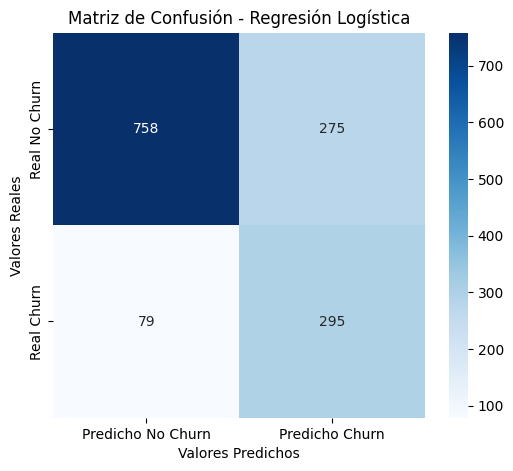

In [ ]:
#  Matriz de Confusión
print("\nMatriz de Confusión:")
conf_matrix_logistica = confusion_matrix(y_test, y_pred_logistica)
display(pd.DataFrame(conf_matrix_logistica,
                     index=['Real No Churn', 'Real Churn'],
                     columns=['Predicho No Churn', 'Predicho Churn']))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_logistica, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho No Churn','Predicho Churn'],
            yticklabels=['Real No Churn', 'Real Churn'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inicializar el modelo de Random Forest
# random_state: para reproducibilidad.
modelo_random_forest = RandomForestClassifier( random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
print("Entrenando el modelo de Random Forest...")
modelo_random_forest.fit(X_train, y_train)
print("Modelo de Random Forest entrenado con éxito.")

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_random_forest = modelo_random_forest.predict(X_test)


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Entrenando el modelo de Random Forest...
Modelo de Random Forest entrenado con éxito.
Random Forest
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.78      1407




--- Evaluación del Modelo de Random Forest ---
Precisión (Accuracy): 0.7953

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.78      1407


Matriz de Confusión:


,Predicho No Churn,Predicho Churn
Real No Churn,937,96
Real Churn,192,182


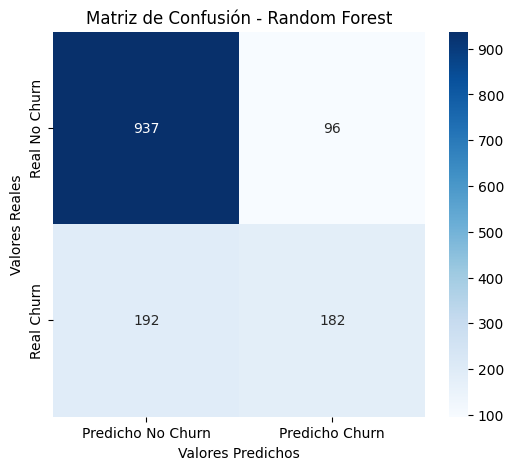

In [ ]:
# 4. Evaluar el rendimiento del modelo
print("\n--- Evaluación del Modelo de Random Forest ---")

# Precisión general
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
print(f"Precisión (Accuracy): {accuracy_random_forest:.4f}")

# Reporte de clasificación (incluye Precision, Recall, F1-score por clase)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_random_forest))

# Matriz de Confusión
print("\nMatriz de Confusión:")
conf_matrix_random_forest = confusion_matrix(y_test, y_pred_random_forest)
display(pd.DataFrame(conf_matrix_random_forest,
                     index=['Real No Churn', 'Real Churn'],
                     columns=['Predicho No Churn', 'Predicho Churn']))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_random_forest, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho No Churn', 'Predicho Churn'],
            yticklabels=['Real No Churn', 'Real Churn'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()


#📋 Interpretación y Conclusiones

In [ ]:
# Obtener los coeficientes del modelo de Regresión Logística
coeficientes = modelo_regresion_logistica.coef_[0]

# Obtener los nombres de las características (columnas de X_train)
nombres_caracteristicas = X_train.columns

# Crear un DataFrame para mostrar los coeficientes y ordenarlos
df_coeficientes_logistica = pd.DataFrame({
    'Característica': nombres_caracteristicas,
    'Coeficiente': coeficientes
})

# Ordenar por el valor absoluto del coeficiente para ver la importancia
df_coeficientes_logistica['Abs_Coeficiente'] = df_coeficientes_logistica['Coeficiente'].abs()
df_coeficientes_logistica = df_coeficientes_logistica.sort_values(by='Abs_Coeficiente', ascending=False)

print("Coeficientes de las variables en el Modelo de Regresión Logística (ordenados por impacto absoluto):\n")
display(df_coeficientes_logistica.drop(columns=['Abs_Coeficiente']))

Coeficientes de las variables en el Modelo de Regresión Logística (ordenados por impacto absoluto):



,Característica,Coeficiente
15,contrato_Two year,-1.337143
6,tipo_de_internet_Fiber optic,1.185497
7,tipo_de_internet_No,-1.152013
14,contrato_One year,-0.720249
12,streaming_tv_1,0.486118
18,metodo_de_pago_Electronic check,0.386002
13,streaming_peliculas_1,0.358954
16,factura_digital_1,0.343855
11,soporte_tecnico_1,-0.303704
5,multiples_lineas_1,0.293201


In [ ]:

# Obtener la importancia de las características del modelo Random Forest
importancias_random_forest = modelo_random_forest.feature_importances_

# Obtener los nombres de las características (columnas de X_train)
nombres_caracteristicas_rf = X_train.columns

# Crear un DataFrame para mostrar las importancias y ordenarlas
df_importancia_random_forest = pd.DataFrame({
    'Característica': nombres_caracteristicas_rf,
    'Importancia': importancias_random_forest
})

# Ordenar por importancia de forma descendente
df_importancia_random_forest = df_importancia_random_forest.sort_values(by='Importancia', ascending=False)

print("Importancia de las variables en el Modelo Random Forest (ordenadas de mayor a menor):\n")
display(df_importancia_random_forest)


Importancia de las variables en el Modelo Random Forest (ordenadas de mayor a menor):



,Característica,Importancia
2,valor_mensual,0.256725
1,tiempo_contrato,0.256174
6,tipo_de_internet_Fiber optic,0.047540
18,metodo_de_pago_Electronic check,0.041517
15,contrato_Two year,0.039798
16,factura_digital_1,0.031136
14,contrato_One year,0.030448
3,tiene_pareja_1,0.028126
8,seguridad_en_linea_1,0.027304
11,soporte_tecnico_1,0.026970


### Análisis del Modelo de Regresión Logística (Basado en Coeficientes):

En el modelo de Regresión Logística, los coeficientes indican la dirección y la magnitud de la relación entre cada característica y la probabilidad de cancelación (Churn). Un coeficiente positivo significa que un aumento en el valor de la característica aumenta la probabilidad de Churn, mientras que un coeficiente negativo la disminuye. Los valores absolutos más grandes indican una mayor influencia.

Basándonos en los coeficientes calculados, las variables más influyentes son:

1.  **`contrato_Two year`** (Coeficiente negativo grande): Tener un contrato de dos años reduce significativamente la probabilidad de cancelación. Esto es lógico, ya que los clientes con contratos a largo plazo suelen estar más comprometidos, y la permanencia contractual es un fuerte indicador de estabilidad.
2.  **`tipo_de_internet_Fiber optic`** (Coeficiente positivo grande): Los clientes con servicio de fibra óptica tienen una mayor probabilidad de cancelación. Esto es una señal crítica; podría sugerir problemas de satisfacción con la calidad o el costo de este servicio, o que es un segmento de clientes más atractivo para la competencia. Se debería investigar a fondo este punto.
3.  **`tipo_de_internet_No`** (Coeficiente negativo grande): La ausencia de servicio de internet reduce la probabilidad de cancelación. Esto podría indicar que los clientes que solo utilizan el servicio telefónico son un segmento más estable y menos propenso a buscar alternativas en el mercado.
4.  **`contrato_One year`** (Coeficiente negativo): Al igual que con el contrato de dos años, un contrato de un año también reduce la probabilidad de Churn, aunque su impacto es menor que el de un contrato más largo. Esto refuerza la idea de que la duración del compromiso contractual es un factor clave.
5.  **`streaming_tv_1`** (Coeficiente positivo): Los clientes que tienen servicio de streaming de TV tienden a tener una mayor probabilidad de cancelación. Esto podría estar relacionado con el coste adicional de este servicio, o que son clientes más orientados al entretenimiento y, por tanto, más sensibles a ofertas de otras plataformas o proveedores.

### Análisis del Modelo Random Forest (Basado en Importancia de Características):

El modelo Random Forest mide la importancia de las características basándose en cuánto contribuye cada una a la reducción de la impureza (por ejemplo, Gini impurity) en el árbol. Valores más altos indican mayor importancia.

Según el Random Forest, las variables más importantes son:

1.  **`valor_mensual`**: Es, con diferencia, la variable más importante. Esto sugiere que el monto que los clientes pagan mensualmente es un factor clave en su decisión de cancelar o no. Un `valor_mensual` alto podría generar insatisfacción si no se percibe un valor equivalente, o si existen ofertas más competitivas en el mercado.
2.  **`tiempo_contrato`**: El tiempo que el cliente lleva con la empresa también es una variable muy relevante, indicando que la antigüedad del cliente es un fuerte predictor de Churn. Los clientes con contratos más cortos son, lógicamente, más propensos a cancelar.
3.  **`tipo_de_internet_Fiber optic`**: Al igual que en la Regresión Logística, el tipo de internet (específicamente la fibra óptica) es un factor importante. Esto subraya la necesidad de analizar la experiencia de los clientes con este servicio.
4.  **`metodo_de_pago_Electronic check`**: El método de pago, particularmente el cheque electrónico, también tiene una importancia considerable. Esto podría deberse a que los clientes que usan este método tienden a ser menos leales o más propensos a una cancelación impulsiva, a diferencia de aquellos con pagos automáticos (tarjeta de crédito o transferencia bancaria).
5.  **`contrato_Two year`**: La duración del contrato, especialmente el de dos años, es otra variable con un peso significativo, confirmando su rol crucial en la retención.

### Conclusión:

Ambos modelos, aunque utilizan metodologías diferentes, **convergen en la identificación de `tiempo_contrato`, `valor_mensual` y el `tipo_de_internet_Fiber optic` como las características más influyentes** en la probabilidad de que un cliente cancele el servicio. La **duración del contrato** se destaca consistentemente como un factor crucial en la retención de clientes.

**Observaciones Clave:**
*   **Impacto de los Contratos a Largo Plazo:** Los clientes con contratos de `One year` y `Two year` tienen una probabilidad significativamente menor de Churn. Esto sugiere que fomentar la suscripción a contratos más largos es una estrategia efectiva de retención.
*   **Preocupación por la Fibra Óptica:** El `tipo_de_internet_Fiber optic` es un fuerte predictor de Churn en ambos modelos. Esto demanda una investigación inmediata sobre la calidad del servicio de fibra óptica, el soporte al cliente para estos usuarios o la existencia de ofertas muy agresivas por parte de la competencia en este segmento.
*   **Sensibilidad al Precio:** El `valor_mensual` es una de las variables más importantes en el Random Forest, indicando que las percepciones sobre el coste del servicio son un motor fundamental para la decisión de cancelar. Es crucial analizar si el `valor_mensual` está alineado con el valor percibido por el cliente y las ofertas del mercado.
*   **Método de Pago:** El `metodo_de_pago_Electronic check` también muestra una relevancia. Los clientes que utilizan este método podrían ser más volátiles, y quizás se les debería ofrecer incentivos para cambiar a métodos de pago automáticos que tienden a estar asociados con mayor lealtad.
*   **Servicios Adicionales (Streaming TV):** El `streaming_tv` puede ser un factor que, si bien aumenta el `valor_mensual`, también incrementa la probabilidad de Churn. Se necesita evaluar si estos servicios adicionales cumplen con las expectativas del cliente o si solo añaden una carga económica sin valor percibido suficiente.

**Recomendaciones Estratégicas:**
1.  **Programas de Fidelización:** Desarrollar programas específicos para clientes de `Fiber optic` para mejorar su satisfacción y reducir la tasa de Churn en este segmento vulnerable.
2.  **Ofertas de Contratos a Largo Plazo:** Incentivar la renovación a contratos de uno o dos años con descuentos o beneficios adicionales para aumentar la retención.
3.  **Análisis de Precios:** Realizar un benchmarking competitivo del `valor_mensual` y ajustar las estrategias de precios para asegurar que sean percibidos como justos y competitivos, especialmente para los planes de fibra óptica.
4.  **Gestión de Métodos de Pago:** Promover métodos de pago automáticos, como tarjetas de crédito o transferencias bancarias directas, ofreciendo pequeñas ventajas o recordatorios para reducir la dependencia del cheque electrónico.
5.  **Monitoreo de Servicios Adicionales:** Evaluar la satisfacción de los clientes con servicios como `streaming_tv` y `streaming_peliculas` para asegurarse de que no se conviertan en un motivo para la cancelación.